<a href="https://colab.research.google.com/github/amanmeka/DataScience/blob/main/Unit3/AmanMekaU3proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 3 Project: Data Analysis of Yiheng's 3x3x3 Solve Times

In [1]:
!pip install "preliz[full,notebook]"
import preliz as pz
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import arviz as az
import pymc as pm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.8/515.8 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.6/519.6 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 37.1 MB/s eta 0:00:00


For this project I chose to analyze the times of Yiheng Wang for solving a 3x3. I downloaded the data from the World Cube Association and filtered through the data to get only Yiheng's solve data. Then, I excluded his first two years of solving because they will negatively bias the data.

## Adding/Parsing Data

In [2]:
fname = "https://raw.githubusercontent.com/amanmeka/DataScience/refs/heads/main/Yiheng333Data.csv"
yiheng = pd.read_csv(fname)

In [ ]:
yiheng

,pos,best,average,value1,value2,value3,value4,value5,competitionId,eventId,roundTypeId,personName,personId,formatId,regionalSingleRecord,regionalAverageRecord,personCountryId
0,2,538,637,618,619,674,724,538,TianjinSummerSolstice2021,333,1,Yiheng Wang (王艺衡),2019WANY36,a,NaN,NaN,China
1,3,603,748,762,805,677,603,807,TianjinSummerSolstice2021,333,2,Yiheng Wang (王艺衡),2019WANY36,a,NaN,NaN,China
2,2,573,681,640,573,778,696,708,TianjinSummerSolstice2021,333,f,Yiheng Wang (王艺衡),2019WANY36,a,NaN,NaN,China
3,1,395,544,520,535,667,395,578,SingaporeChampionship2023,333,1,Yiheng Wang (王艺衡),2019WANY36,a,NaN,NaN,China
4,1,470,491,478,470,553,519,475,SingaporeChampionship2023,333,2,Yiheng Wang (王艺衡),2019WANY36,a,NaN,AsR,China
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244,1,401,436,450,509,453,401,404,TaizhouOpen2025,333,f,Yiheng Wang (王艺衡),2019WANY36,a,NaN,NaN,China
245,1,391,470,448,413,549,637,391,ZiboOpen2025,333,1,Yiheng Wang (王艺衡),2019WANY36,a,NaN,NaN,China
246,2,467,483,659,488,489,467,472,ZiboOpen2025,333,2,Yiheng Wang (王艺衡),2019WANY36,a,NaN,NaN,China
247,2,418,468,564,463,460,418,480,ZiboOpen2025,333,f,Yiheng Wang (王艺衡),2019WANY36,a,NaN,NaN,China


I want to view all of his solve data in one list so I will iterate through every element and add it to a list. I will exclude the data that is -1 because that means that he did not solve the cube. He only "DNFed" about 12 times so it is better if I just remove them because they will mess up my data analysis.

In [4]:
list = []
n = yiheng['value1'].size
total = 0
for i in range (0,n):
  for r in range (0,5):
    if r == 0:
      num = yiheng['value1'][i]
      if num != -1:
        list.append(num/100)
        total+=num/100
    elif r == 1:
      num = yiheng['value2'][i]
      if num != -1:
        list.append(num/100)
        total+=num/100
    elif r == 2:
      num = yiheng['value3'][i]
      if num != -1:
        list.append(num/100)
        total+=num/100
    elif r == 3:
      num = yiheng['value4'][i]
      if num != -1:
        list.append(num/100)
        total+=num/100
    elif r == 4:
      num = yiheng['value5'][i]
      if num != -1:
        list.append(num/100)
        total+=num/100

In [ ]:
list

[np.float64(6.18),
 np.float64(6.19),
 np.float64(6.74),
 np.float64(7.24),
 np.float64(5.38),
 np.float64(7.62),
 np.float64(8.05),
 np.float64(6.77),
 np.float64(6.03),
 np.float64(8.07),
 np.float64(6.4),
 np.float64(5.73),
 np.float64(7.78),
 np.float64(6.96),
 np.float64(7.08),
 np.float64(5.2),
 np.float64(5.35),
 np.float64(6.67),
 np.float64(3.95),
 np.float64(5.78),
 np.float64(4.78),
 np.float64(4.7),
 np.float64(5.53),
 np.float64(5.19),
 np.float64(4.75),
 np.float64(5.86),
 np.float64(5.55),
 np.float64(7.69),
 np.float64(5.2),
 np.float64(5.63),
 np.float64(6.12),
 np.float64(5.07),
 np.float64(5.1),
 np.float64(5.77),
 np.float64(5.14),
 np.float64(4.32),
 np.float64(6.21),
 np.float64(4.49),
 np.float64(4.99),
 np.float64(7.51),
 np.float64(4.96),
 np.float64(4.77),
 np.float64(5.97),
 np.float64(5.45),
 np.float64(7.49),
 np.float64(4.27),
 np.float64(4.99),
 np.float64(5.82),
 np.float64(5.34),
 np.float64(5.78),
 np.float64(6.13),
 np.float64(5.6),
 np.float64(5.51),

(array([ 83., 479., 392., 183.,  62.,  23.,   5.,   3.,   1.,   2.]),
 array([ 3.06 ,  3.918,  4.776,  5.634,  6.492,  7.35 ,  8.208,  9.066,
         9.924, 10.782, 11.64 ]),
 <BarContainer object of 10 artists>)

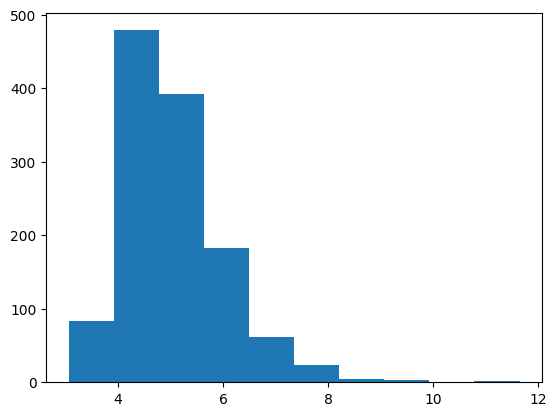

In [5]:
plt.hist(list)

After looking at the histogram, I concur that the mean of Yiheng over all of his solves for the last ~4 years is about 5 seconds.

## First

For this iteration I want my likelihood to be Normal. There are a few things that I want to note about this distribution:
* The domain is 0 to infinity
* The mean is $\mu$
* The variance is $\sigma^2$

The mean for my first prior(Half Normal) is equal to $\sigma \times \frac{\sqrt{2}}{\sqrt{π}}$ and I estimate the mean to be 5 so sigma is around 6.25.

And I estimate the variance to be around 1 second so the next prior(InverseGamma) should have an alpha of 21 and a beta of 20

Therefore I want my $\mu$ to be ~5 and my $\sigma$ to be 1

### Prior #1 ($\alpha$)

<Axes: >

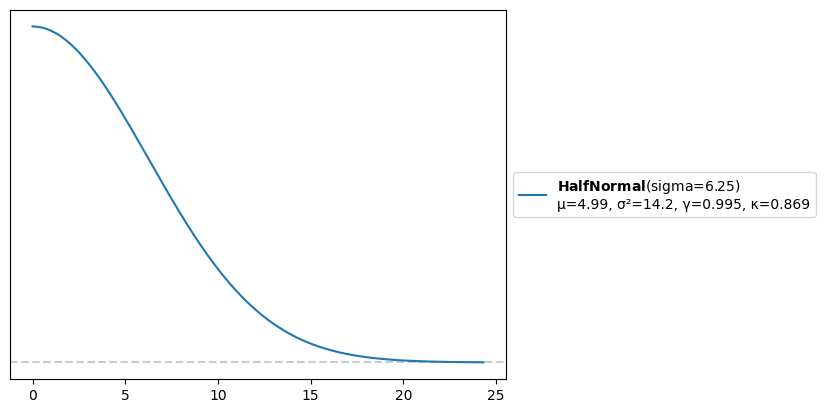

In [ ]:
pz.HalfNormal(sigma=6.25).plot_pdf(moments='mvsk')

### Prior #2 ($\beta$)

<Axes: >

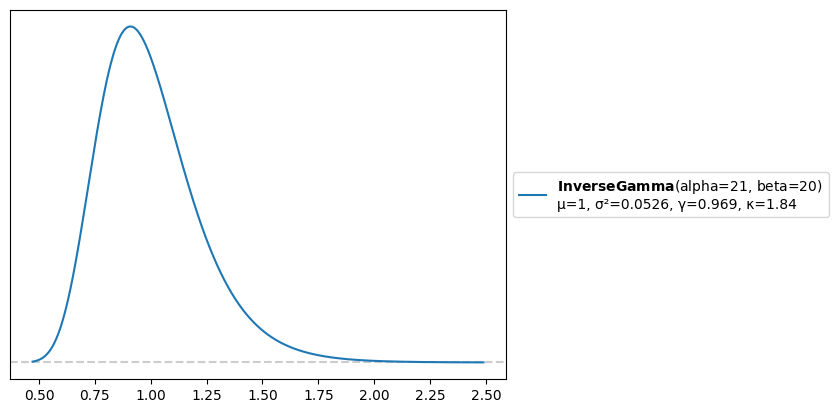

In [ ]:
pz.InverseGamma(alpha=21,beta=20).plot_pdf(moments='mvsk')

### Posterior Predictive ($\alpha$, $\beta$)

In [ ]:
#N for normal
with pm.Model() as normal_yiheng:

    a = pm.HalfNormal('a', sigma=6.25)

    b = pm.InverseGamma('b', alpha=21,beta=20)

    #our fancy new likelihood, with two priors
    Y = pm.Normal('Y', mu = a, sigma = b, observed=list)
    normal_list = pm.sample(1000, progressbar=False)

array([<Axes: title={'center': 'a'}>, <Axes: title={'center': 'b'}>],
      dtype=object)

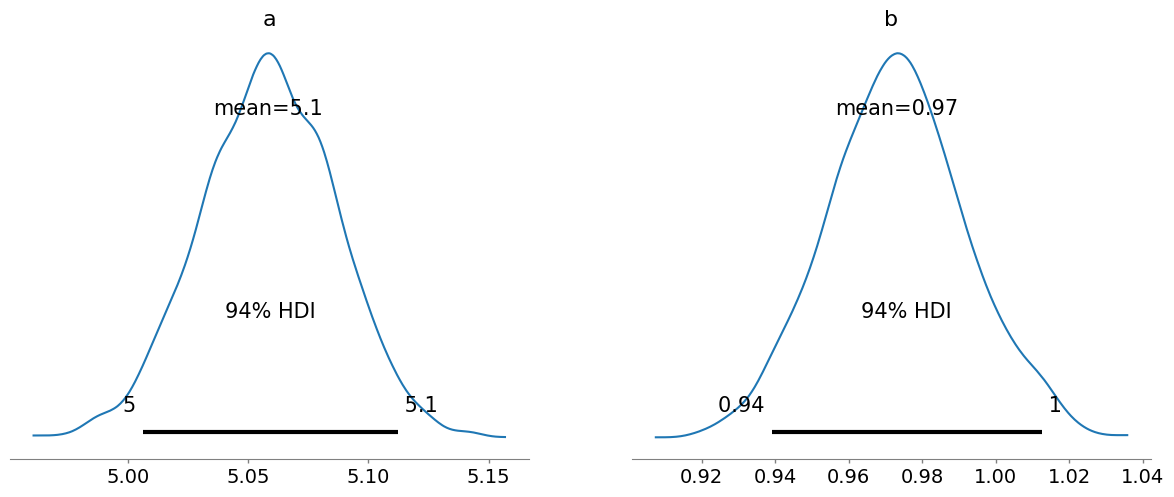

In [ ]:
az.plot_posterior(normal_list)

array([[<Axes: >, None],
       [<Axes: xlabel='a', ylabel='b'>, <Axes: >]], dtype=object)

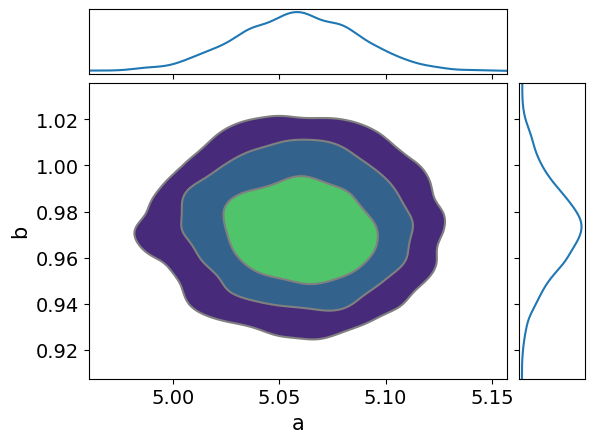

In [ ]:
az.plot_pair(normal_list, kind='kde', marginals=True)

In [ ]:
pm.sample_posterior_predictive(normal_list, model=normal_yiheng, extend_inferencedata=True, progressbar=False)

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

<Axes: xlabel='Y'>

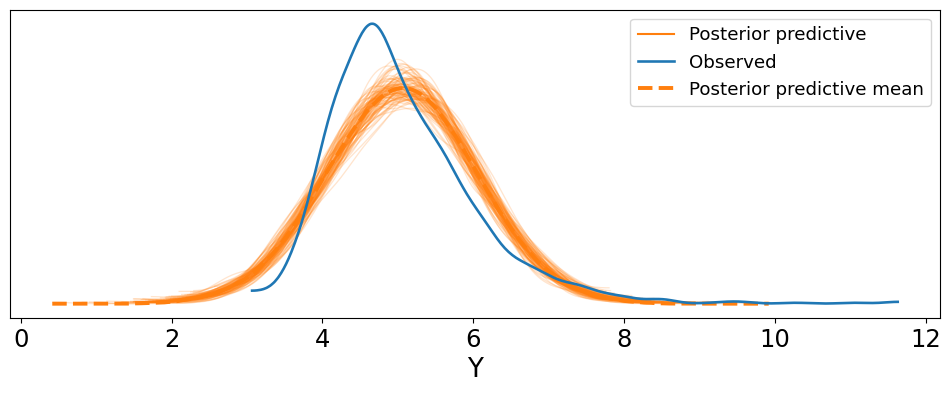

In [ ]:
az.plot_ppc(normal_list, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

### Takeaways

This posterior predictive is okay but I want it to be closer to the observed data's curve.

#### Mean
The mean looks like it is slightly more than the observed data.

#### Variance
The variance is similar but the places where there is deviation is different between the observed data and the predictive posterior mean.

#### Skew
The posterior predictive mean has no skew but the observed data looks like it is skewed

#### Kurtosis
It looks like the kurtosis is higher in the observed data than the posterior predictive mean. The posterior predictive mean looks more like a normal distribution, or mesokurtic.

## First Iteration


For this iteration I want my likelihood to be Gamma. There are a few things that I want to note about this distribution:
* The domain is 0 to infinity
* The mean is $\dfrac{\alpha}{\beta}$
* The variance is $\dfrac{\alpha}{\beta^2}$

The first prior's mean should be around 25 because the likelihood's input is alpha and beta where the mean is $\frac{a}{b}$ and the variance is $\frac{a}{b^2}$

The mean of the second prior should be around 5 because the likelihood's input is alpha and beta where the mean is $\frac{a}{b}$ and the variance is $\frac{a}{b^2}$

Therefore I want my $\alpha$ to be ~25 and my $\beta$ to be ~5

### Prior #1 ($\alpha$)

<Axes: >

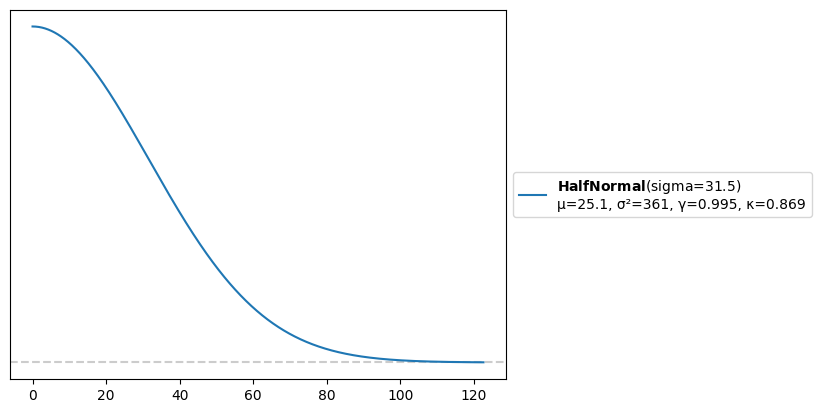

In [ ]:
pz.HalfNormal(sigma=31.5).plot_pdf(moments="mvsk")

### Prior #2 ($\beta$)

<Axes: >

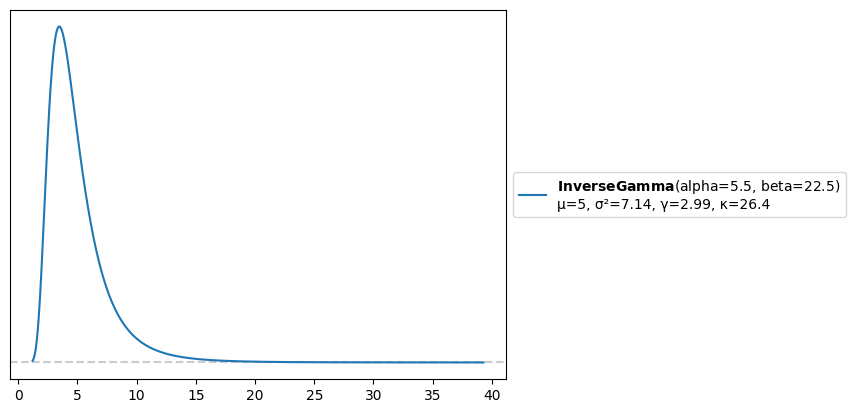

In [ ]:
pz.InverseGamma(alpha=5.5,beta=22.5).plot_pdf(moments="mvsk")

### Posterior Predictive ($\alpha$, $\beta$)

In [23]:
#N for normal
with pm.Model() as gamma_yiheng:

    a = pm.HalfNormal('a', sigma=31.5)

    b = pm.InverseGamma('b', alpha=5.5,beta=22.5)

    #our fancy new likelihood, with two priors
    Y = pm.Gamma('Y', alpha = a, beta = b, observed=list)
    gamma_list = pm.sample(1000, progressbar=False)

array([<Axes: title={'center': 'a'}>, <Axes: title={'center': 'b'}>],
      dtype=object)

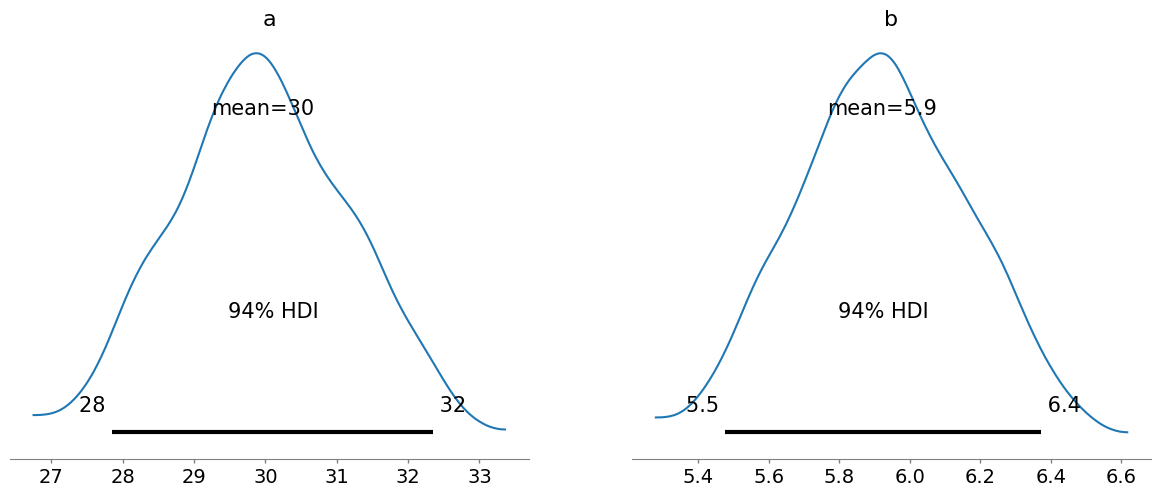

In [24]:
az.plot_posterior(gamma_list)

array([[<Axes: >, None],
       [<Axes: xlabel='a', ylabel='b'>, <Axes: >]], dtype=object)

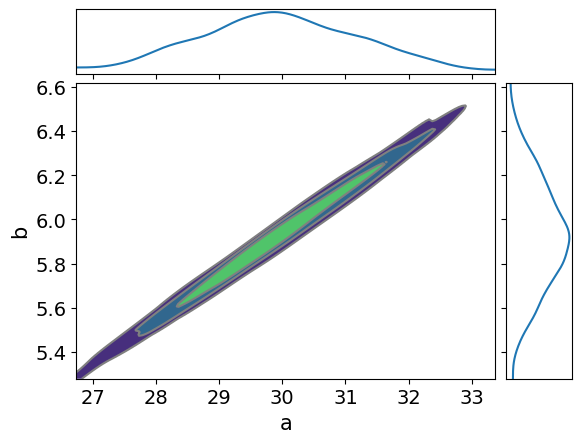

In [25]:
az.plot_pair(gamma_list, kind='kde', marginals=True)

In [26]:
pm.sample_posterior_predictive(gamma_list, model=gamma_yiheng, extend_inferencedata=True, progressbar=False)

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

<Axes: xlabel='Y'>

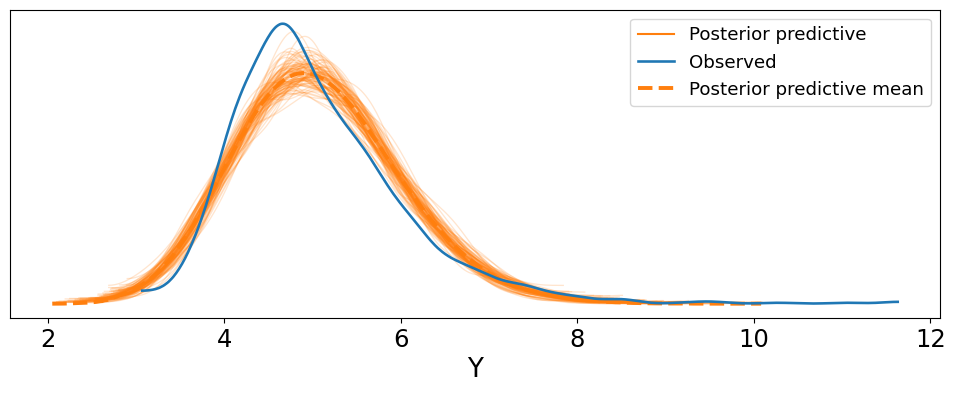

In [30]:
az.plot_ppc(gamma_list, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

### Takeaways

This posterior prediction is much better than the last one because it fits the curve better. But I think I can do much better.

#### Mean
The mean looks like it is almost exactly like the mean from the observed data. Even though the peaks are not at the same place, the mean looks to be equal.

#### Variance
The variance is similar but the places where there is deviation is different between the observed data and the predictive posterior mean just like the last graph.

#### Skew
The posterior predictive mean has very minimal skew but the observed data looks like it is much more skewed

#### Kurtosis
It looks like the kurtosis is greater in the observed data (blue line) than the posterior predictive mean again. The posterior predictive mean looks more like a normal distribution, or mesokurtic.

## Second Iteration

For this iteration I want my likelihood to be Log Normal. There are a few things that I want to note about this distribution:
* The domain is 0 to infinity
* The mean is $\exp\left(\mu+\frac{\sigma^2}{2}\right)$
* The variance is $[\exp(\sigma^2)-1] \exp(2\mu+\sigma^2)$

Therefore I want my $\mu$ to be ~1.4 and my $\sigma$ to be ~0.6

### Prior #1 ($\mu$)

<Axes: >

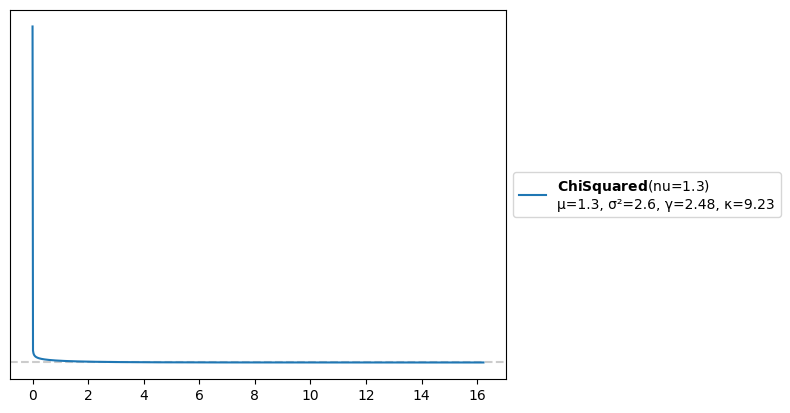

In [6]:
pz.ChiSquared(nu=1.3).plot_pdf(moments="mvsk")

### Prior #2 ($\sigma$)

np.float64(0.591504516152557)

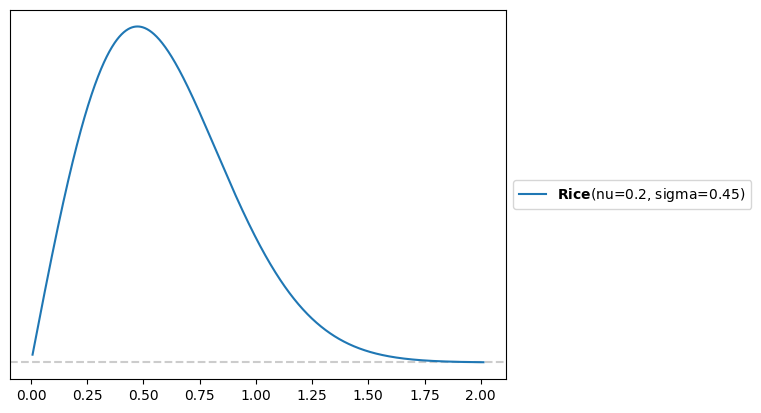

In [12]:
n=0.2
s=0.45
pz.Rice(nu=n,sigma=s).plot_pdf()
pz.Rice(nu=n,sigma=s).mean()

### Posterior Predictive ($\mu$, $\sigma$)

In [13]:
#
with pm.Model() as log_yiheng:

    m = pm.ChiSquared('m', nu=1.3)

    s = pm.Rice('s', nu=0.2,sigma=0.45)

    #our fancy new likelihood, with two priors
    y = pm.LogNormal('y', mu = m, sigma = s, observed=list)
    log_list = pm.sample(1000, progressbar=False)

array([<Axes: title={'center': 'm'}>, <Axes: title={'center': 's'}>],
      dtype=object)

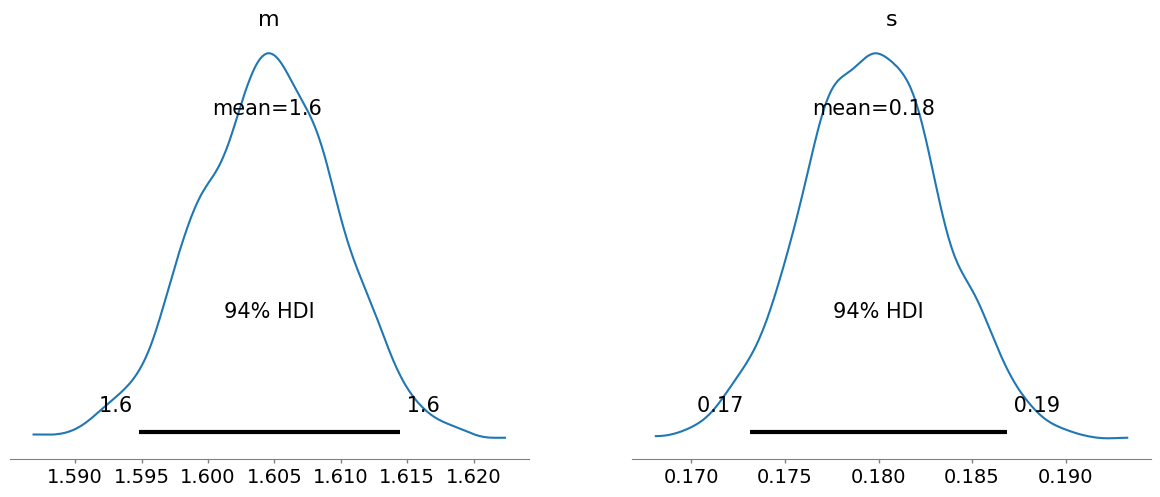

In [16]:
az.plot_posterior(log_list)

array([[<Axes: >, None],
       [<Axes: xlabel='m', ylabel='s'>, <Axes: >]], dtype=object)

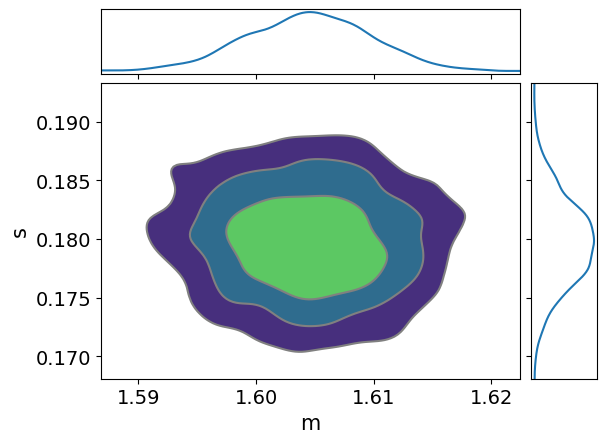

In [17]:
az.plot_pair(log_list, kind='kde', marginals=True)

In [18]:
pm.sample_posterior_predictive(log_list, model=log_yiheng, extend_inferencedata=True, progressbar=False)

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

<Axes: xlabel='y'>

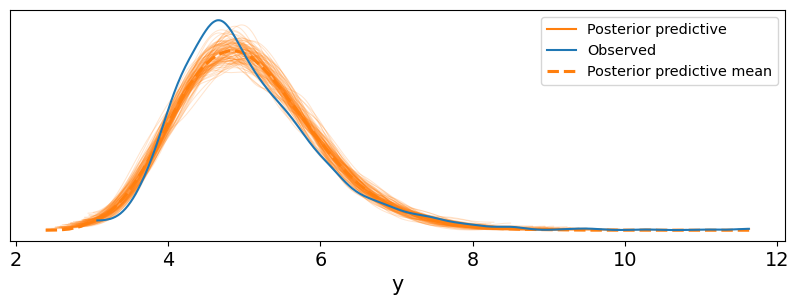

In [19]:
az.plot_ppc(log_list, num_pp_samples=100, figsize=(10, 3), colors=["C1", "C0", "C1"])

### Takeaways

This is very slightly better than the last one and I think this might be the best one that I can produce.

#### Mean
The mean looks like it is around the mean of the observed data.

#### Variance
The variance is around the same but the areas in which there is variation is different between the observed data and the predictive posterior mean. The observed data has a bit of a skew to the variance

#### Skew
The posterior predictive mean has a tiny bit of skew but the observed data looks like it is much more skewed

#### Kurtosis
It looks like the kurtosis is only slightly higher in the observed data than the posterior predictive mean. The posterior predictive mean is around mesokurtic. Also the trails for the observed data look more flat.

## Conclusion

I think that the last iteration of the posterior predictive mean is close to what Yiheng's times are. The only problem is that the data set might have been slightly negatively biased by his worse times because he is much better of a cuber right now. Therefore, even though the posterior predictive mean matches up closely to the observed data, it might be less matched up to his more recent times. I think in the future, I can bias the times that are more recent or get rid of times from the past.